In [1]:
import scanpy as sc
import celltypist
from celltypist import models
import pyreadr
import scipy
import pandas as pd
import numpy as np

In [2]:
data_set = 'Alveolar_full'

In [21]:
adata = sc.read_h5ad('/home/sjcho/projects/AT2_MHC2/20241113_after_cellbender/manuscript_figures/figure4/figure4_and_exd6_20250225/w_cycling_IFN.h5ad')

In [22]:
from scipy import sparse
adata.X = sparse.csr_matrix(adata.X)
adata.X.expm1().sum(axis = 1)

matrix([[10000.],
        [10000.],
        [10000.],
        ...,
        [10000.],
        [10000.],
        [10000.]])

In [26]:
alveolar_regeneration_reference_prediction = celltypist.annotate(adata, majority_voting = True, over_clustering = 'RNA_snn_res.1', model = '/home/sjcho/datas/reference_atlas/mouse_lung_alveolar/outs/20250217_public_figures/merged_w_GSE262927_full_celltypist_model.pkl')

🔬 Input data has 5949 cells and 32285 genes
🔗 Matching reference genes in the model
🧬 1141 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🗳️ Majority voting the predictions
✅ Majority voting done!


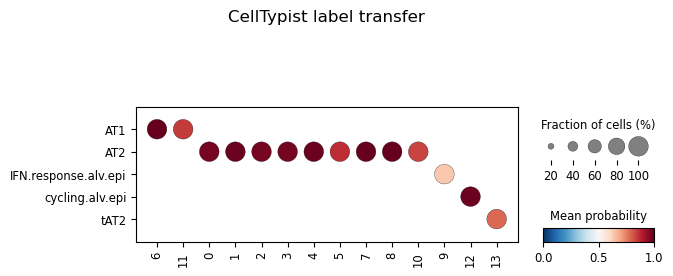

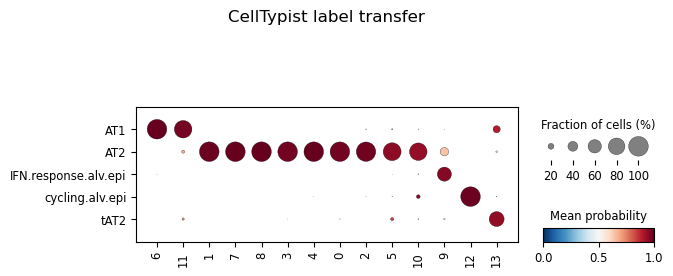

In [27]:
celltypist.dotplot(alveolar_regeneration_reference_prediction, use_as_reference = 'RNA_snn_res.1', use_as_prediction = 'majority_voting')
celltypist.dotplot(alveolar_regeneration_reference_prediction, use_as_reference = 'RNA_snn_res.1', use_as_prediction = 'predicted_labels')

In [28]:
adata_predicted = alveolar_regeneration_reference_prediction.to_adata()
adata_predicted.obs[['predicted_labels', 'over_clustering', 'majority_voting', 'conf_score']].to_csv('/home/sjcho/projects/AT2_MHC2/20241113_after_cellbender/manuscript_figures/figure4/figure4_and_exd6_20250225/' + 'alv_full_celltypist_result_overcluster1.csv')